<a href="https://colab.research.google.com/github/srabani-khuntia/LLM_Using_Python/blob/main/4th_June.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import random_split
import matplotlib.pyplot as plt
from torch import nn
from datasets import load_dataset

In [ ]:
from datasets import load_dataset

dataset = load_dataset("fancyzhx/ag_news")

train_set = dataset["train"]
test_set = dataset["test"]

train_iter = iter(train_set)
test_iter = iter(test_set)

train_set_map = train_set
test_set_map = test_set

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [ ]:
print(f"Training set size: {(train_set_map)}")
print(f"Test set size: {len(test_set_map)}")

labels_set={label for label, _ in train_set_map}
print("The set of unique labels: {labels_set}")

Training set size: Dataset({
    features: ['text', 'label'],
    num_rows: 120000
})
Test set size: 7600
The set of unique labels: {labels_set}


In [ ]:
#Create a pytorch tensor of labels

labels_list = [item['label'] for item in train_set_map]
labels_tensor = torch.tensor(labels_list)

#Count the frequency of each label
unique_labels, counts = torch.unique(labels_tensor, return_counts=True)

# Corrected label_dict for 0-indexed labels
label_dict = {0:"World", 1:"Sports", 2:"Business", 3:"Science & Technology"}

#Print some samples for each label
print_sample_size = 2
for label in unique_labels:
  count = 0
  print(f"\nSamples for label '{label_dict[label.item()]}':")
  for item in train_set_map:
    if item['label'] == label.item():
      print(f"  - {item['text']}")
      count += 1
      if count >= print_sample_size:
        break

  print("----------------------------------------------------")


Samples for label 'World':
  - Venezuelans Vote Early in Referendum on Chavez Rule (Reuters) Reuters - Venezuelans turned out early\and in large numbers on Sunday to vote in a historic referendum\that will either remove left-wing President Hugo Chavez from\office or give him a new mandate to govern for the next two\years.
  - S.Koreans Clash with Police on Iraq Troop Dispatch (Reuters) Reuters - South Korean police used water cannon in\central Seoul Sunday to disperse at least 7,000 protesters\urging the government to reverse a controversial decision to\send more troops to Iraq.
----------------------------------------------------

Samples for label 'Sports':
  - Phelps, Thorpe Advance in 200 Freestyle (AP) AP - Michael Phelps took care of qualifying for the Olympic 200-meter freestyle semifinals Sunday, and then found out he had been added to the American team for the evening's 400 freestyle relay final. Phelps' rivals Ian Thorpe and Pieter van den Hoogenband and teammate Klete Kelle

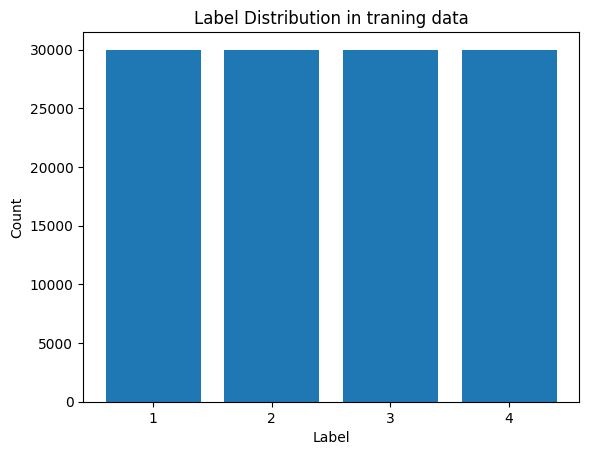

In [ ]:
#Plotting the histogram of the label distribution:
plt.bar(unique_labels, counts, tick_label = list(range(1,5)))
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Label Distribution in traning data")
plt.show()